In [1]:
import numpy as np   
import pandas as pd    
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import matplotlib.pyplot as plt   
import matplotlib.style

In [2]:
df=pd.read_csv("cubic_zirconia.csv")

In [3]:
df.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,x,y,z,price
0,1,0.30,Ideal,E,SI1,62.1,58.0,4.27,4.29,2.66,499
1,2,0.33,Premium,G,IF,60.8,58.0,4.42,4.46,2.70,984
2,3,0.90,Very Good,E,VVS2,62.2,60.0,6.04,6.12,3.78,6289
3,4,0.42,Ideal,F,VS1,61.6,56.0,4.82,4.80,2.96,1082
4,5,0.31,Ideal,F,VVS1,60.4,59.0,4.35,4.43,2.65,779


In [4]:
df.shape

(26967, 11)

In [5]:
df.isnull().sum()

Unnamed: 0      0
carat           0
cut             0
color           0
clarity         0
depth         697
table           0
x               0
y               0
z               0
price           0
dtype: int64

In [6]:
df.dtypes

Unnamed: 0      int64
carat         float64
cut            object
color          object
clarity        object
depth         float64
table         float64
x             float64
y             float64
z             float64
price           int64
dtype: object

In [7]:
df.describe()

,Unnamed: 0,carat,depth,table,x,y,z,price
count,26967.000000,26967.000000,26270.000000,26967.000000,26967.000000,26967.000000,26967.000000,26967.000000
mean,13484.000000,0.798375,61.745147,57.456080,5.729854,5.733569,3.538057,3939.518115
std,7784.846691,0.477745,1.412860,2.232068,1.128516,1.166058,0.720624,4024.864666
min,1.000000,0.200000,50.800000,49.000000,0.000000,0.000000,0.000000,326.000000
25%,6742.500000,0.400000,61.000000,56.000000,4.710000,4.710000,2.900000,945.000000
50%,13484.000000,0.700000,61.800000,57.000000,5.690000,5.710000,3.520000,2375.000000
75%,20225.500000,1.050000,62.500000,59.000000,6.550000,6.540000,4.040000,5360.000000
max,26967.000000,4.500000,73.600000,79.000000,10.230000,58.900000,31.800000,18818.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26967 entries, 0 to 26966
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  26967 non-null  int64  
 1   carat       26967 non-null  float64
 2   cut         26967 non-null  object 
 3   color       26967 non-null  object 
 4   clarity     26967 non-null  object 
 5   depth       26270 non-null  float64
 6   table       26967 non-null  float64
 7   x           26967 non-null  float64
 8   y           26967 non-null  float64
 9   z           26967 non-null  float64
 10  price       26967 non-null  int64  
dtypes: float64(6), int64(2), object(3)
memory usage: 2.3+ MB


In [12]:
for column in df.columns:
    if df[column].dtype != 'object':
        mean = df[column].mean()
        df[column] = df[column].fillna(mean)    
        
df.isnull().sum()      

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
x             0
y             0
z             0
price         0
dtype: int64

In [63]:
df.duplicated().sum()

40

In [15]:
df.describe()

,Unnamed: 0,carat,depth,table,x,y,z,price
count,26967.000000,26967.000000,26967.000000,26967.000000,26967.000000,26967.000000,26967.000000,26967.000000
mean,13484.000000,0.798375,61.745147,57.456080,5.729854,5.733569,3.538057,3939.518115
std,7784.846691,0.477745,1.394481,2.232068,1.128516,1.166058,0.720624,4024.864666
min,1.000000,0.200000,50.800000,49.000000,0.000000,0.000000,0.000000,326.000000
25%,6742.500000,0.400000,61.100000,56.000000,4.710000,4.710000,2.900000,945.000000
50%,13484.000000,0.700000,61.800000,57.000000,5.690000,5.710000,3.520000,2375.000000
75%,20225.500000,1.050000,62.500000,59.000000,6.550000,6.540000,4.040000,5360.000000
max,26967.000000,4.500000,73.600000,79.000000,10.230000,58.900000,31.800000,18818.000000


In [16]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [17]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z',
       'price'],
      dtype='object')

In [18]:
df.describe()

,carat,depth,table,x,y,z,price
count,26967.000000,26967.000000,26967.000000,26967.000000,26967.000000,26967.000000,26967.000000
mean,0.798375,61.745147,57.456080,5.729854,5.733569,3.538057,3939.518115
std,0.477745,1.394481,2.232068,1.128516,1.166058,0.720624,4024.864666
min,0.200000,50.800000,49.000000,0.000000,0.000000,0.000000,326.000000
25%,0.400000,61.100000,56.000000,4.710000,4.710000,2.900000,945.000000
50%,0.700000,61.800000,57.000000,5.690000,5.710000,3.520000,2375.000000
75%,1.050000,62.500000,59.000000,6.550000,6.540000,4.040000,5360.000000
max,4.500000,73.600000,79.000000,10.230000,58.900000,31.800000,18818.000000


In [19]:
def univariateAnalysis_numeric(column):
    
    plt.figure()
    print("Distribution of " + column)
    print("----------------------------------------------------------------------------")
    sns.distplot(df[column], kde=True, color='g');
    plt.show()
    
    plt.figure()
    print("BoxPlot of " + column)
    print("----------------------------------------------------------------------------")
    ax = sns.boxplot(x=df[column])
    plt.show()

In [20]:
df_num = df.select_dtypes(include = ['float64', 'int64'])
lstnumericcolumns = list(df_num.columns)
len(lstnumericcolumns)

7

Distribution of carat
----------------------------------------------------------------------------


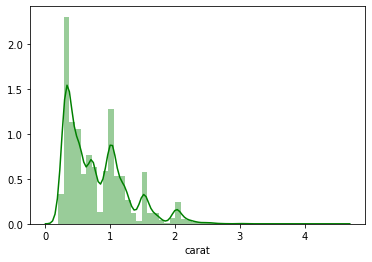

BoxPlot of carat
----------------------------------------------------------------------------


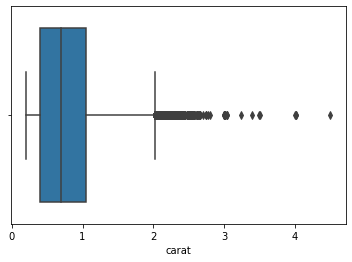

Distribution of depth
----------------------------------------------------------------------------


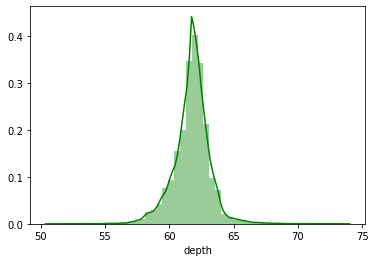

BoxPlot of depth
----------------------------------------------------------------------------


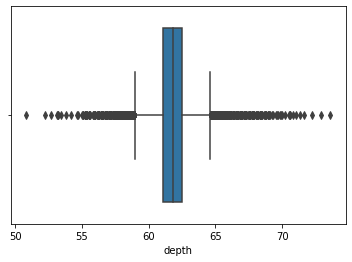

Distribution of table
----------------------------------------------------------------------------


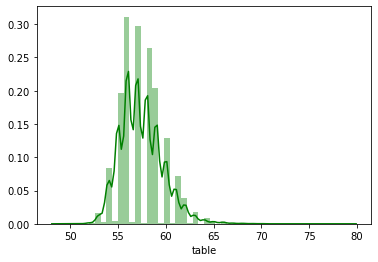

BoxPlot of table
----------------------------------------------------------------------------


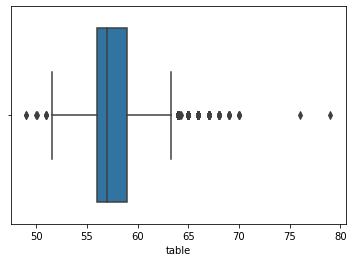

Distribution of x
----------------------------------------------------------------------------


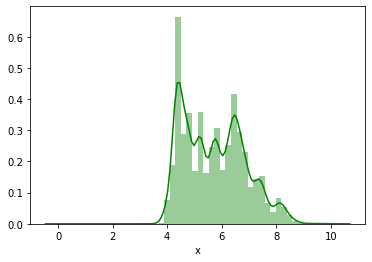

BoxPlot of x
----------------------------------------------------------------------------


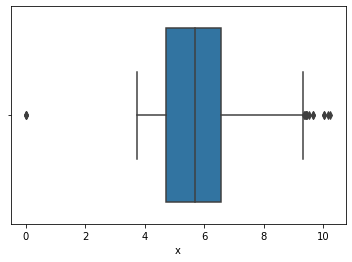

Distribution of y
----------------------------------------------------------------------------


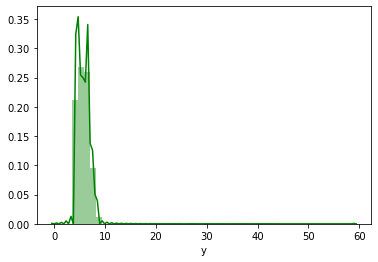

BoxPlot of y
----------------------------------------------------------------------------


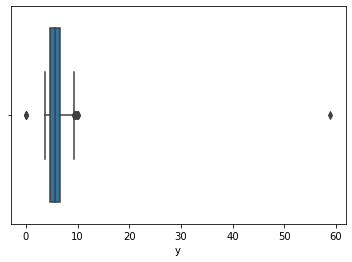

Distribution of z
----------------------------------------------------------------------------


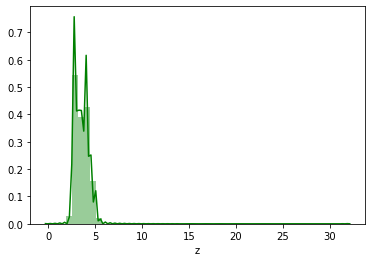

BoxPlot of z
----------------------------------------------------------------------------


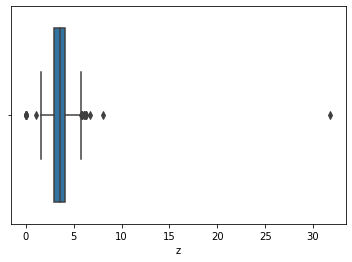

Distribution of price
----------------------------------------------------------------------------


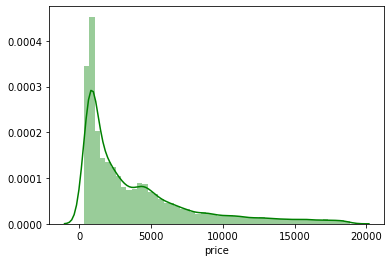

BoxPlot of price
----------------------------------------------------------------------------


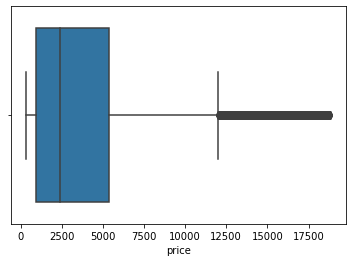

In [21]:
for x in lstnumericcolumns:
    univariateAnalysis_numeric(x)
   

In [22]:
print("KURTOSIS")
df_num.kurtosis()

KURTOSIS


carat      1.215364
depth      3.851502
table      1.582166
x         -0.657825
y        159.291616
z         87.006350
price      2.148617
dtype: float64

In [23]:
print("SKEWNESS")
df_num.skew()

SKEWNESS


carat    1.116481
depth   -0.028995
table    0.765758
x        0.387986
y        3.850189
z        2.568257
price    1.618550
dtype: float64

In [24]:
def univariateAnalysis_category(cat_column):
    print("Details of " + cat_column)
    print("----------------------------------------------------------------")
    print(df_cat[cat_column].value_counts())
    print("       ")

In [25]:
df_cat = df.select_dtypes(include = ['object'])
lstcatcolumns = list(df_cat.columns.values)
lstcatcolumns

['cut', 'color', 'clarity']

In [26]:
for x in lstcatcolumns:
    univariateAnalysis_category(x)

Details of cut
----------------------------------------------------------------
Ideal        10816
Premium       6899
Very Good     6030
Good          2441
Fair           781
Name: cut, dtype: int64
       
Details of color
----------------------------------------------------------------
G    5661
E    4917
F    4729
H    4102
D    3344
I    2771
J    1443
Name: color, dtype: int64
       
Details of clarity
----------------------------------------------------------------
SI1     6571
VS2     6099
SI2     4575
VS1     4093
VVS2    2531
VVS1    1839
IF       894
I1       365
Name: clarity, dtype: int64
       


In [27]:
corr = df_num.corr(method='pearson')

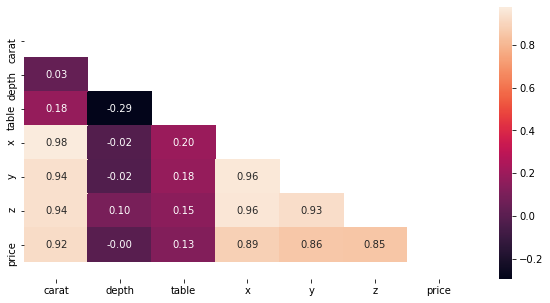

In [28]:
mask = np.triu(np.ones_like(corr, dtype=np.bool)) 
fig = plt.subplots(figsize=(10, 5))
ax=sns.heatmap(df_num.corr(), annot=True,fmt='.2f',mask=mask)
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
plt.show()

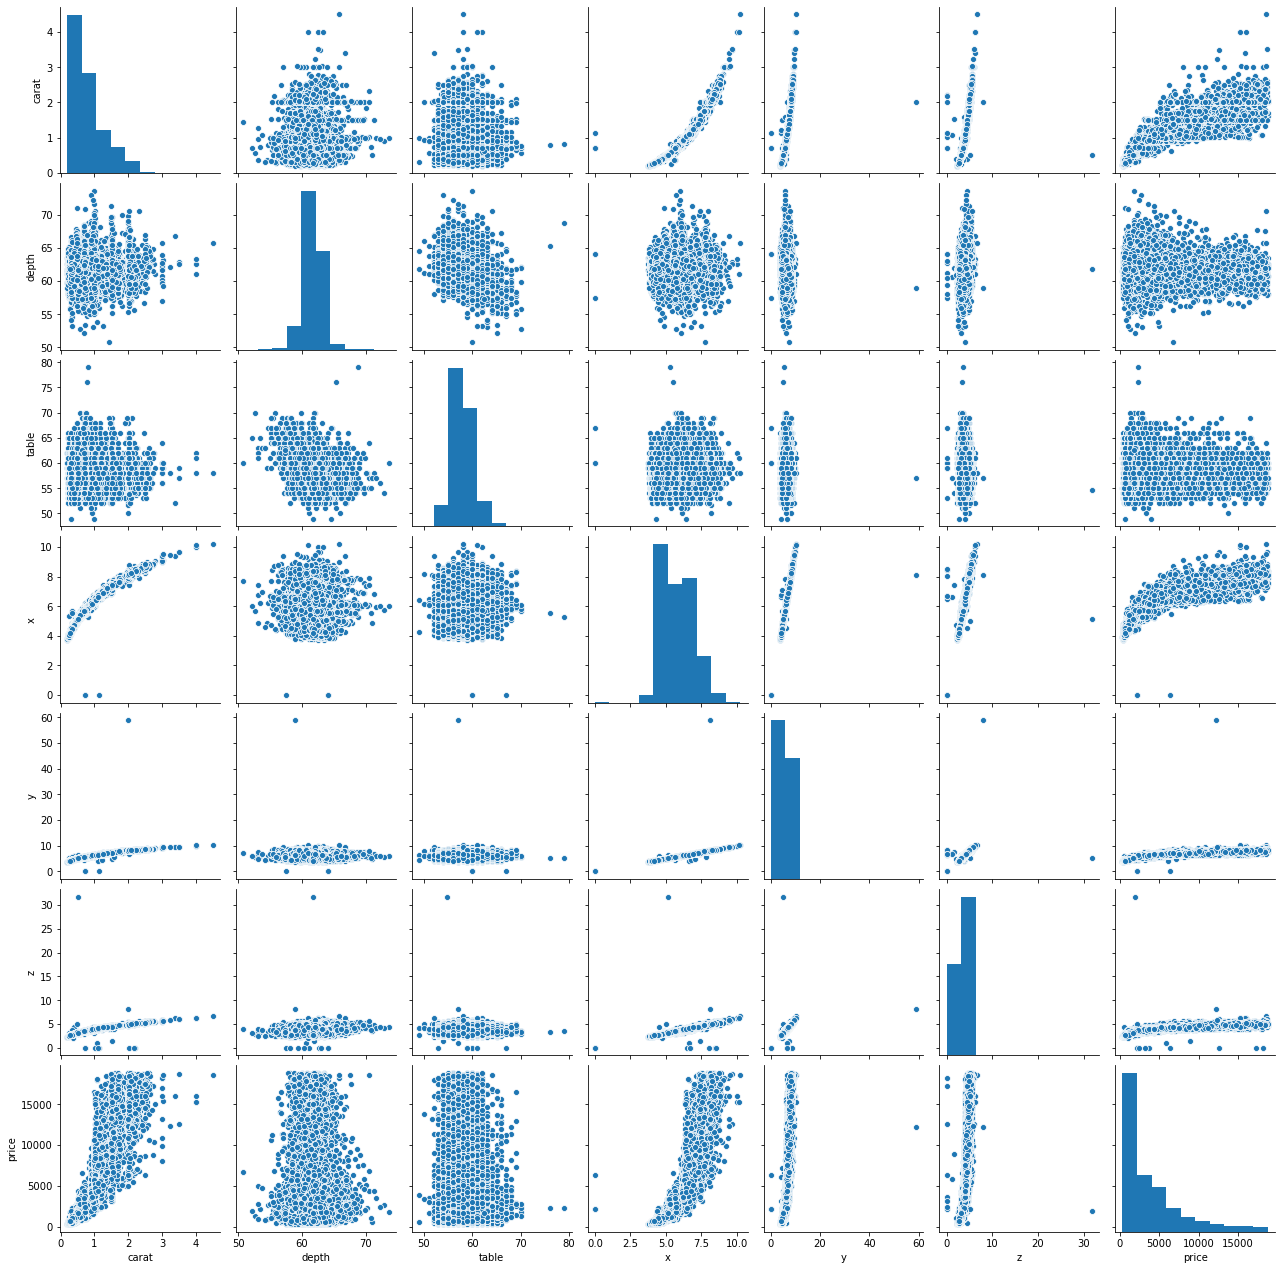

In [29]:
sns.pairplot(df_num)

In [30]:
def treat_outlier(x):
    # taking 5,25,75 percentile of column
    q5= np.percentile(x,5)
    q25=np.percentile(x,25)
    q75=np.percentile(x,75)
    dt=np.percentile(x,95)
    #calculationg IQR range
    IQR=q75-q25
    #Calculating minimum threshold
    lower_bound=q25-(1.5*IQR)
    upper_bound=q75+(1.5*IQR)
    #Capping outliers
    return x.apply(lambda y: dt if y > upper_bound else y).apply(lambda y: q5 if y < lower_bound else y)

In [31]:
no_outlier=["carat"]

In [32]:
outlier_list = [x for x in df_num.columns if x not in no_outlier]

In [33]:
outlier_list

['depth', 'table', 'x', 'y', 'z', 'price']

In [34]:
for i in df[outlier_list]:    
    df[i]=treat_outlier(df[i])

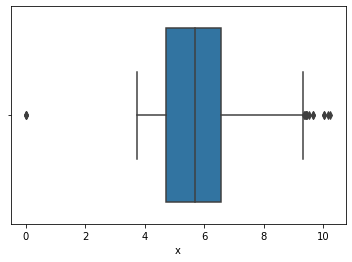

In [35]:
sns.boxplot(df_num["x"])

In [36]:
for feature in df.columns: 
    if df[feature].dtype == 'object':
        df[feature] = pd.Categorical(df[feature]).codes

      

In [37]:
df.describe()

,carat,cut,color,clarity,depth,table,x,y,z,price
count,26967.000000,26967.000000,26967.000000,26967.000000,26967.000000,26967.000000,26967.000000,26967.000000,26967.000000,26967.000000
mean,0.798375,2.554604,2.606111,3.833537,61.741865,57.407702,5.729438,5.731334,3.537316,3819.406282
std,0.477745,1.024243,1.705992,1.724904,1.162176,2.090151,1.124638,1.116593,0.694826,3672.176838
min,0.200000,0.000000,0.000000,0.000000,59.000000,51.600000,3.730000,3.710000,1.530000,326.000000
25%,0.400000,2.000000,1.000000,2.000000,61.100000,56.000000,4.710000,4.710000,2.900000,945.000000
50%,0.700000,2.000000,3.000000,4.000000,61.800000,57.000000,5.690000,5.710000,3.520000,2375.000000
75%,1.050000,3.000000,4.000000,5.000000,62.500000,59.000000,6.550000,6.540000,4.040000,5360.000000
max,4.500000,4.000000,6.000000,7.000000,64.600000,63.300000,9.300000,9.260000,5.750000,13217.800000


In [79]:
df.head(5)

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.30,2,1,2,62.1,58.0,4.27,4.29,2.66,499.0
1,0.33,3,3,1,60.8,58.0,4.42,4.46,2.70,984.0
2,0.90,4,1,7,62.2,60.0,6.04,6.12,3.78,6289.0
3,0.42,2,2,4,61.6,56.0,4.82,4.80,2.96,1082.0
4,0.31,2,2,6,60.4,59.0,4.35,4.43,2.65,779.0


In [38]:
# Copy all the predictor variables into X dataframe
X = df.drop('price', axis=1)

# Copy target into the y dataframe. 
y = df[['price']]

In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30 , random_state=1)

In [80]:
print("X_train data",X_train.shape)
print("X_test data",X_test.shape)
print("y_train data",y_train.shape)
print("y_test data",y_test.shape)



X_train data (18876, 9)
X_test data (8091, 9)
y_train data (18876, 1)
y_test data (8091, 1)


In [40]:
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

LinearRegression()

In [41]:
for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, regression_model.coef_[0][idx]))

The coefficient for carat is 7446.640501598327
The coefficient for cut is 56.388246351218385
The coefficient for color is -237.65810946580208
The coefficient for clarity is 277.2916815587658
The coefficient for depth is -19.900044228390545
The coefficient for table is -76.98525871030027
The coefficient for x is -1479.23120386297
The coefficient for y is 2120.4465526670638
The coefficient for z is -855.5132903074292


In [43]:
 

intercept = regression_model.intercept_[0]

print("The intercept for our model is {}".format(intercept))

The intercept for our model is 2295.7683581946717


In [44]:
regression_model.score(X_train, y_train)

0.8928845328774478

In [45]:
regression_model.score(X_test, y_test)

0.8937641561744614

In [46]:
regression_model.score(X_test, y_test)

0.8937641561744614

In [47]:
#RMSE on Training data
predicted_train=regression_model.fit(X_train, y_train).predict(X_train)
np.sqrt(metrics.mean_squared_error(y_train,predicted_train))

1204.9315636153806

In [48]:
#RMSE on Testing data
predicted_test=regression_model.fit(X_train, y_train).predict(X_test)
np.sqrt(metrics.mean_squared_error(y_test,predicted_test))

1189.6257731981389

##Linear Regression using statsmodels

In [49]:
# concatenate X and y into a single dataframe
data_train = pd.concat([X_train, y_train], axis=1)
data_test=pd.concat([X_test,y_test],axis=1)
data_train.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
11687,0.41,2,5,7,62.3,56.0,4.77,4.73,2.96,1061.0
9728,1.71,2,6,2,62.8,57.0,7.58,7.55,4.75,6320.0
1936,0.33,1,2,2,61.8,62.0,4.40,4.45,2.74,536.0
26220,0.70,4,4,2,62.8,57.0,5.61,5.66,3.54,2214.0
18445,0.70,2,0,3,62.1,56.0,5.67,5.71,3.53,2575.0


In [50]:
import statsmodels.formula.api as smf
lm1 = smf.ols(formula= 'price ~ carat+cut+color+clarity+depth+table+x+y+z', data = data_train).fit()
lm1.params

Intercept    2295.768358
carat        7446.640502
cut            56.388246
color        -237.658109
clarity       277.291682
depth         -19.900044
table         -76.985259
x           -1479.231204
y            2120.446553
z            -855.513290
dtype: float64

In [51]:
print(lm1.summary())  #Inferential statistics

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.893
Model:                            OLS   Adj. R-squared:                  0.893
Method:                 Least Squares   F-statistic:                 1.747e+04
Date:                Sat, 02 Oct 2021   Prob (F-statistic):               0.00
Time:                        01:21:18   Log-Likelihood:            -1.6069e+05
No. Observations:               18876   AIC:                         3.214e+05
Df Residuals:                   18866   BIC:                         3.215e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2295.7684    891.694      2.575      0.0

In [54]:
mse = np.mean((lm1.predict(data_train.drop('price',axis=1))-data_train['price'])**2)
np.sqrt(mse)

1204.9315636153835

In [55]:
np.sqrt(lm1.mse_resid)

1205.250860746781

In [56]:
# Prediction on Test data
y_pred = lm1.predict(data_test)

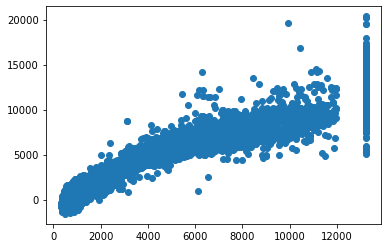

In [58]:
plt.scatter(y_test['price'], y_pred)
plt.show()

In [59]:
for i,j in np.array(lm1.params.reset_index()):
    print('({}) * {} +'.format(round(j,2),i),end=' ')

(2295.77) * Intercept + (7446.64) * carat + (56.39) * cut + (-237.66) * color + (277.29) * clarity + (-19.9) * depth + (-76.99) * table + (-1479.23) * x + (2120.45) * y + (-855.51) * z + 

In [60]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [61]:
vif = [variance_inflation_factor(X.values, ix) for ix in range(X.shape[1])] 

In [62]:
i=0
for column in X.columns:
    if i < 11:
        print (column ,"--->",  vif[i])
        i = i+1



carat ---> 79.18576657780956
cut ---> 7.737406747428161
color ---> 3.672825764621055
clarity ---> 6.282186253512676
depth ---> 889.5849951611906
table ---> 743.2971860891761
x ---> 10030.151153035125
y ---> 9332.10314973534
z ---> 2260.3610644476103


In [66]:
## Iteration two ## 

In [64]:
sd=df.copy ()

In [65]:
sd

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.30,2,1,2,62.1,58.0,4.27,4.29,2.66,499.0
1,0.33,3,3,1,60.8,58.0,4.42,4.46,2.70,984.0
2,0.90,4,1,7,62.2,60.0,6.04,6.12,3.78,6289.0
3,0.42,2,2,4,61.6,56.0,4.82,4.80,2.96,1082.0
4,0.31,2,2,6,60.4,59.0,4.35,4.43,2.65,779.0
...,...,...,...,...,...,...,...,...,...,...
26962,1.11,3,3,2,62.3,58.0,6.61,6.52,4.09,5408.0
26963,0.33,2,4,1,61.9,55.0,4.44,4.42,2.74,1114.0
26964,0.51,3,1,5,61.7,58.0,5.12,5.15,3.17,1656.0
26965,0.27,4,2,7,61.8,56.0,4.19,4.20,2.60,682.0


In [67]:
from scipy.stats import zscore

X_train_scaled  = X_train.apply(zscore)
X_test_scaled = X_test.apply(zscore)
y_train_scaled = y_train.apply(zscore)
y_test_scaled = y_test.apply(zscore)


In [68]:
regression_model = LinearRegression()
regression_model.fit(X_train_scaled, y_train_scaled)

LinearRegression()

In [69]:
for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, regression_model.coef_[0][idx]))

The coefficient for carat is 0.9670143901339374
The coefficient for cut is 0.01574327093700589
The coefficient for color is -0.11010610235962862
The coefficient for clarity is 0.12938346277008178
The coefficient for depth is -0.006293962587540115
The coefficient for table is -0.04361532577697431
The coefficient for x is -0.45129396633934277
The coefficient for y is 0.6423868844859537
The coefficient for z is -0.16135392441689378


In [70]:
intercept = regression_model.intercept_[0]

print("The intercept for our model is {}".format(intercept))

The intercept for our model is 2.836878191270491e-16


In [71]:
# Model score - R2 or coeff of determinant
# R^2=1–RSS / TSS

regression_model.score(X_test_scaled, y_test_scaled)

0.8938931479131532

In [72]:
# Let us check the sum of squared errors by predicting value of y for training cases and 
# subtracting from the actual y for the training cases

mse = np.mean((regression_model.predict(X_test_scaled)-y_test_scaled)**2)

In [73]:
# underroot of mean_sq_error is standard deviation i.e. avg variance between predicted and actual

import math

math.sqrt(mse)

0.32574046737678586

In [74]:

y_pred = regression_model.predict(X_test_scaled)

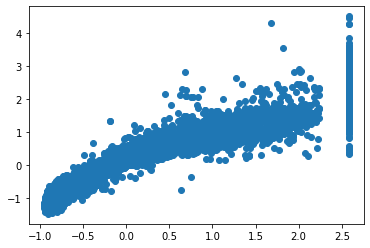

In [76]:
# Since this is regression, plot the predicted y value vs actual y values for the test data
# A good model's prediction will be close to actual leading to high R and R2 values
plt.scatter(y_test_scaled['price'], y_pred)

In [81]:
# concatenate X and y into a single dataframe
data_train_scaled = pd.concat([X_train_scaled, y_train_scaled], axis=1)
data_test_scaled=pd.concat([X_test_scaled,y_test_scaled],axis=1)
data_train_scaled.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
11687,-0.811481,-0.546431,1.401996,1.852795,0.477463,-0.676994,-0.852944,-0.896963,-0.830546,-0.750632
9728,1.907677,-0.546431,1.988276,-1.057867,0.906864,-0.197556,1.648821,1.631423,1.747342,0.677824
1936,-0.978814,-1.519306,-0.356843,-1.057867,0.048061,2.199632,-1.182358,-1.148009,-1.147381,-0.893233
26220,-0.204900,1.399320,0.815717,-1.057867,0.906864,-0.197556,-0.105086,-0.063134,0.004747,-0.437452
18445,-0.204900,-0.546431,-1.529403,-0.475735,0.305702,-0.676994,-0.051667,-0.018304,-0.009654,-0.339397


In [82]:
import statsmodels.formula.api as smf
lm2 = smf.ols(formula= 'price ~ carat+cut+color+clarity+depth+table+x+y+z', data = data_train_scaled).fit()
lm2.params

Intercept   -4.748806e-17
carat        9.670144e-01
cut          1.574327e-02
color       -1.101061e-01
clarity      1.293835e-01
depth       -6.293963e-03
table       -4.361533e-02
x           -4.512940e-01
y            6.423869e-01
z           -1.613539e-01
dtype: float64

In [83]:
print(lm1.summary())  #Inferential statistics

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.893
Model:                            OLS   Adj. R-squared:                  0.893
Method:                 Least Squares   F-statistic:                 1.747e+04
Date:                Sat, 02 Oct 2021   Prob (F-statistic):               0.00
Time:                        11:53:20   Log-Likelihood:            -1.6069e+05
No. Observations:               18876   AIC:                         3.214e+05
Df Residuals:                   18866   BIC:                         3.215e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2295.7684    891.694      2.575      0.0

In [84]:
mse1 = np.mean((lm2.predict(data_train_scaled.drop('price',axis=1))-data_train_scaled['price'])**2)
np.sqrt(mse1)

0.32728499373260617

In [86]:
import math

math.sqrt(mse1)

0.32728499373260617

In [87]:
y_pred_scaled = lm2.predict(data_test_scaled)

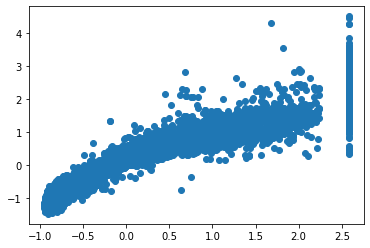

In [88]:
plt.scatter(y_test_scaled['price'], y_pred_scaled)
plt.show()

In [90]:
for k,h in np.array(lm2.params.reset_index()):
    print('({}) * {} +'.format(round(h,4),k),end=' ')

(-0.0) * Intercept + (0.967) * carat + (0.0157) * cut + (-0.1101) * color + (0.1294) * clarity + (-0.0063) * depth + (-0.0436) * table + (-0.4513) * x + (0.6424) * y + (-0.1614) * z + 